# Notebook 06 — Heatmap Analysis

Performance comparison across pooling heads and fine-tuning strategies (patch size = 8).

| Notebook | Strategy |
|---|---|
| NB02 | Frozen encoder |
| NB03 | Mask fine-tuning |
| NB04 | Full fine-tuning |
| NB05 | LoRA / DoRA / AdaLoRA |

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

dfs = []
for nb in ['nb02', 'nb03', 'nb04', 'nb05']:
    path = Path(f'results_csv/{nb}_results.csv')
    if path.exists():
        dfs.append(pd.read_csv(path))
    else:
        print(f'Missing: {path}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'{len(df_all)} rows loaded')
display(df_all.head(10))

112 rows loaded


,finetuning,pooling,patch_size,accuracy,macro_recall,macro_f1
0,02_Frozen,Mean,8,0.611517,0.363178,0.376169
1,02_Frozen,Attention-shared,8,0.596918,0.358135,0.372340
2,02_Frozen,Attention-indep,8,0.603812,0.355907,0.366543
3,02_Frozen,MHA-shared,8,0.618816,0.376281,0.388403
4,02_Frozen,MHA-indep,8,0.611922,0.380971,0.396139
5,02_Frozen,Hierarchical-shared,8,0.575020,0.325842,0.315856
6,02_Frozen,Hierarchical-indep,8,0.611517,0.357908,0.358963
7,02_Frozen,Mean,16,0.618005,NaN,NaN
8,02_Frozen,Attention-shared,16,0.608273,NaN,NaN
9,02_Frozen,Attention-indep,16,0.609489,NaN,NaN


In [45]:
FINETUNING_ORDER = ['02_Frozen', '03_MaskFT', '04_FullFT', '05_LoRA']
FT_LABELS = {'02_Frozen': 'Frozen', '03_MaskFT': 'MaskFT', '04_FullFT': 'FullFT', '05_LoRA': 'LoRA'}

POOLING_ORDER = [
    'Mean',
    'Attention-shared', 'Attention-indep',
    'MHA-shared',       'MHA-indep',
    'Hierarchical-shared', 'Hierarchical-indep',
]
GROUP_BOUNDARIES = [1, 3, 5]

PATCH_SIZES = [8, 16, 32, 64]

sns.set_theme(style='whitegrid', font_scale=1.05)


def draw_heatmap(ax, pivot, cmap, vmin, vmax, metric_label):
    mask  = pivot.isnull()
    annot = pivot.copy().astype(object)
    annot[mask] = ''
    sns.heatmap(pivot.astype(float), ax=ax, annot=annot, fmt='',
                cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': metric_label, 'shrink': 0.7}, mask=mask)
    for t in ax.texts:
        try: t.set_text(f'{float(t.get_text()):.3f}')
        except ValueError: pass
    for b in GROUP_BOUNDARIES:
        ax.axhline(b, color='#333333', linewidth=1.5)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

## Patch Size = 8 — Accuracy & Macro Recall

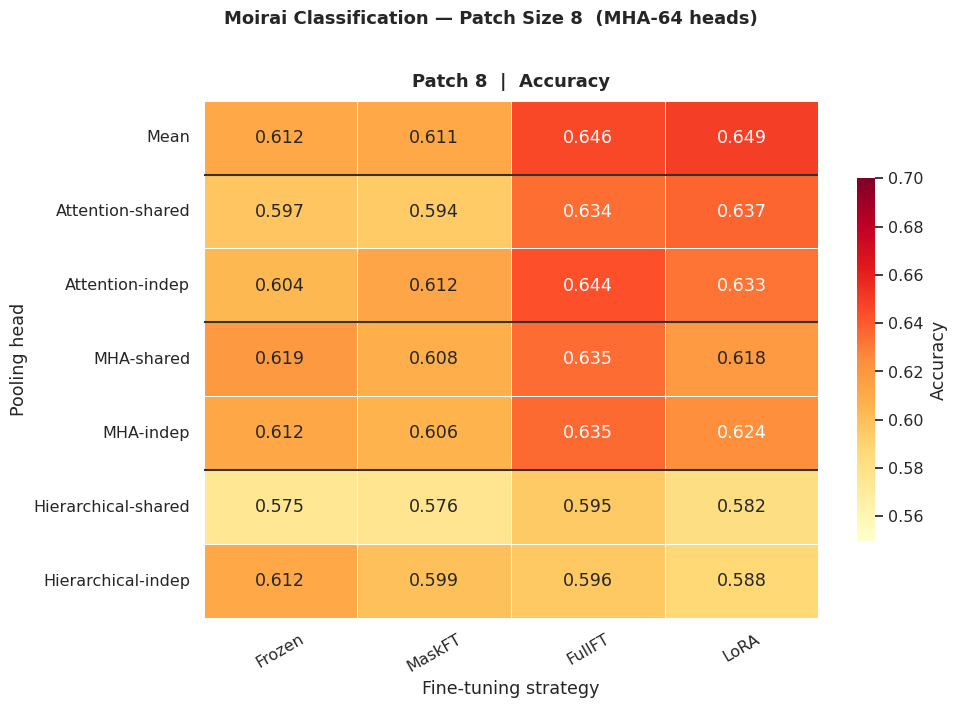

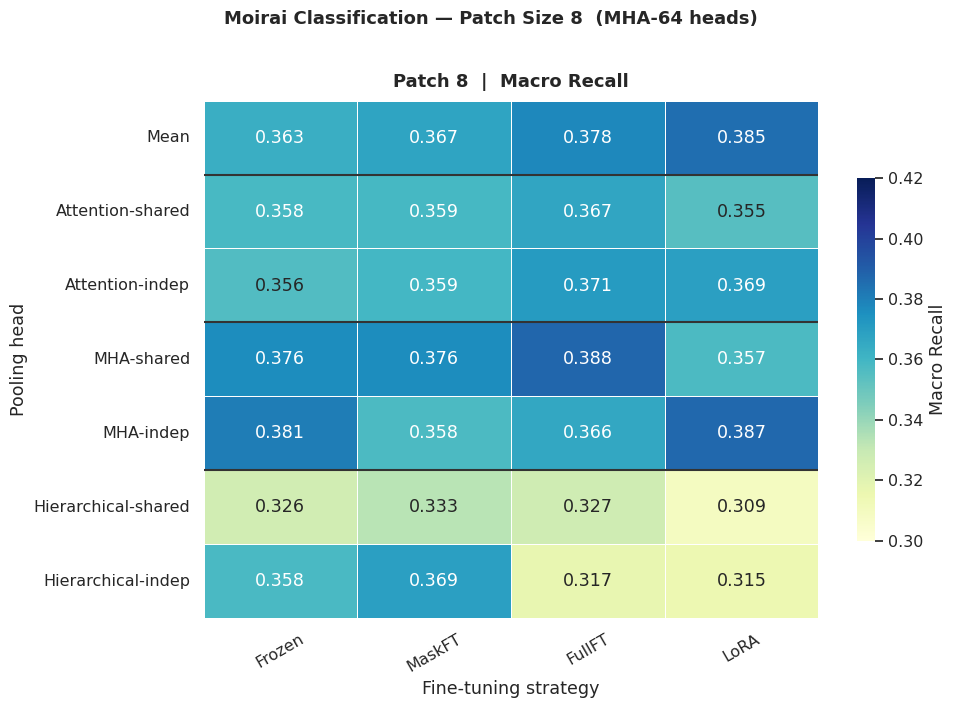

In [46]:
df_8 = df_all[df_all['patch_size'] == 8].copy()

for metric, label, vmin, vmax, cmap, fname in [
    ('accuracy',    'Accuracy',    0.55, 0.70, 'YlOrRd', 'results_csv/heatmap_patch8_accuracy.png'),
    ('macro_recall','Macro Recall',0.30, 0.42, 'YlGnBu', 'results_csv/heatmap_patch8_recall.png'),
]:
    pivot = (df_8.pivot_table(index='pooling', columns='finetuning', values=metric, aggfunc='first')
               .reindex(index=POOLING_ORDER, columns=FINETUNING_ORDER))
    pivot.columns = [FT_LABELS[c] for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(10, 7))
    draw_heatmap(ax, pivot, cmap, vmin, vmax, label)
    ax.set_title(f'Patch 8  |  {label}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Fine-tuning strategy')
    ax.set_ylabel('Pooling head')
    plt.suptitle('Moirai Classification — Patch Size 8  (MHA-64 heads)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

## Accuracy across Patch Sizes (8, 16, 32, 64)

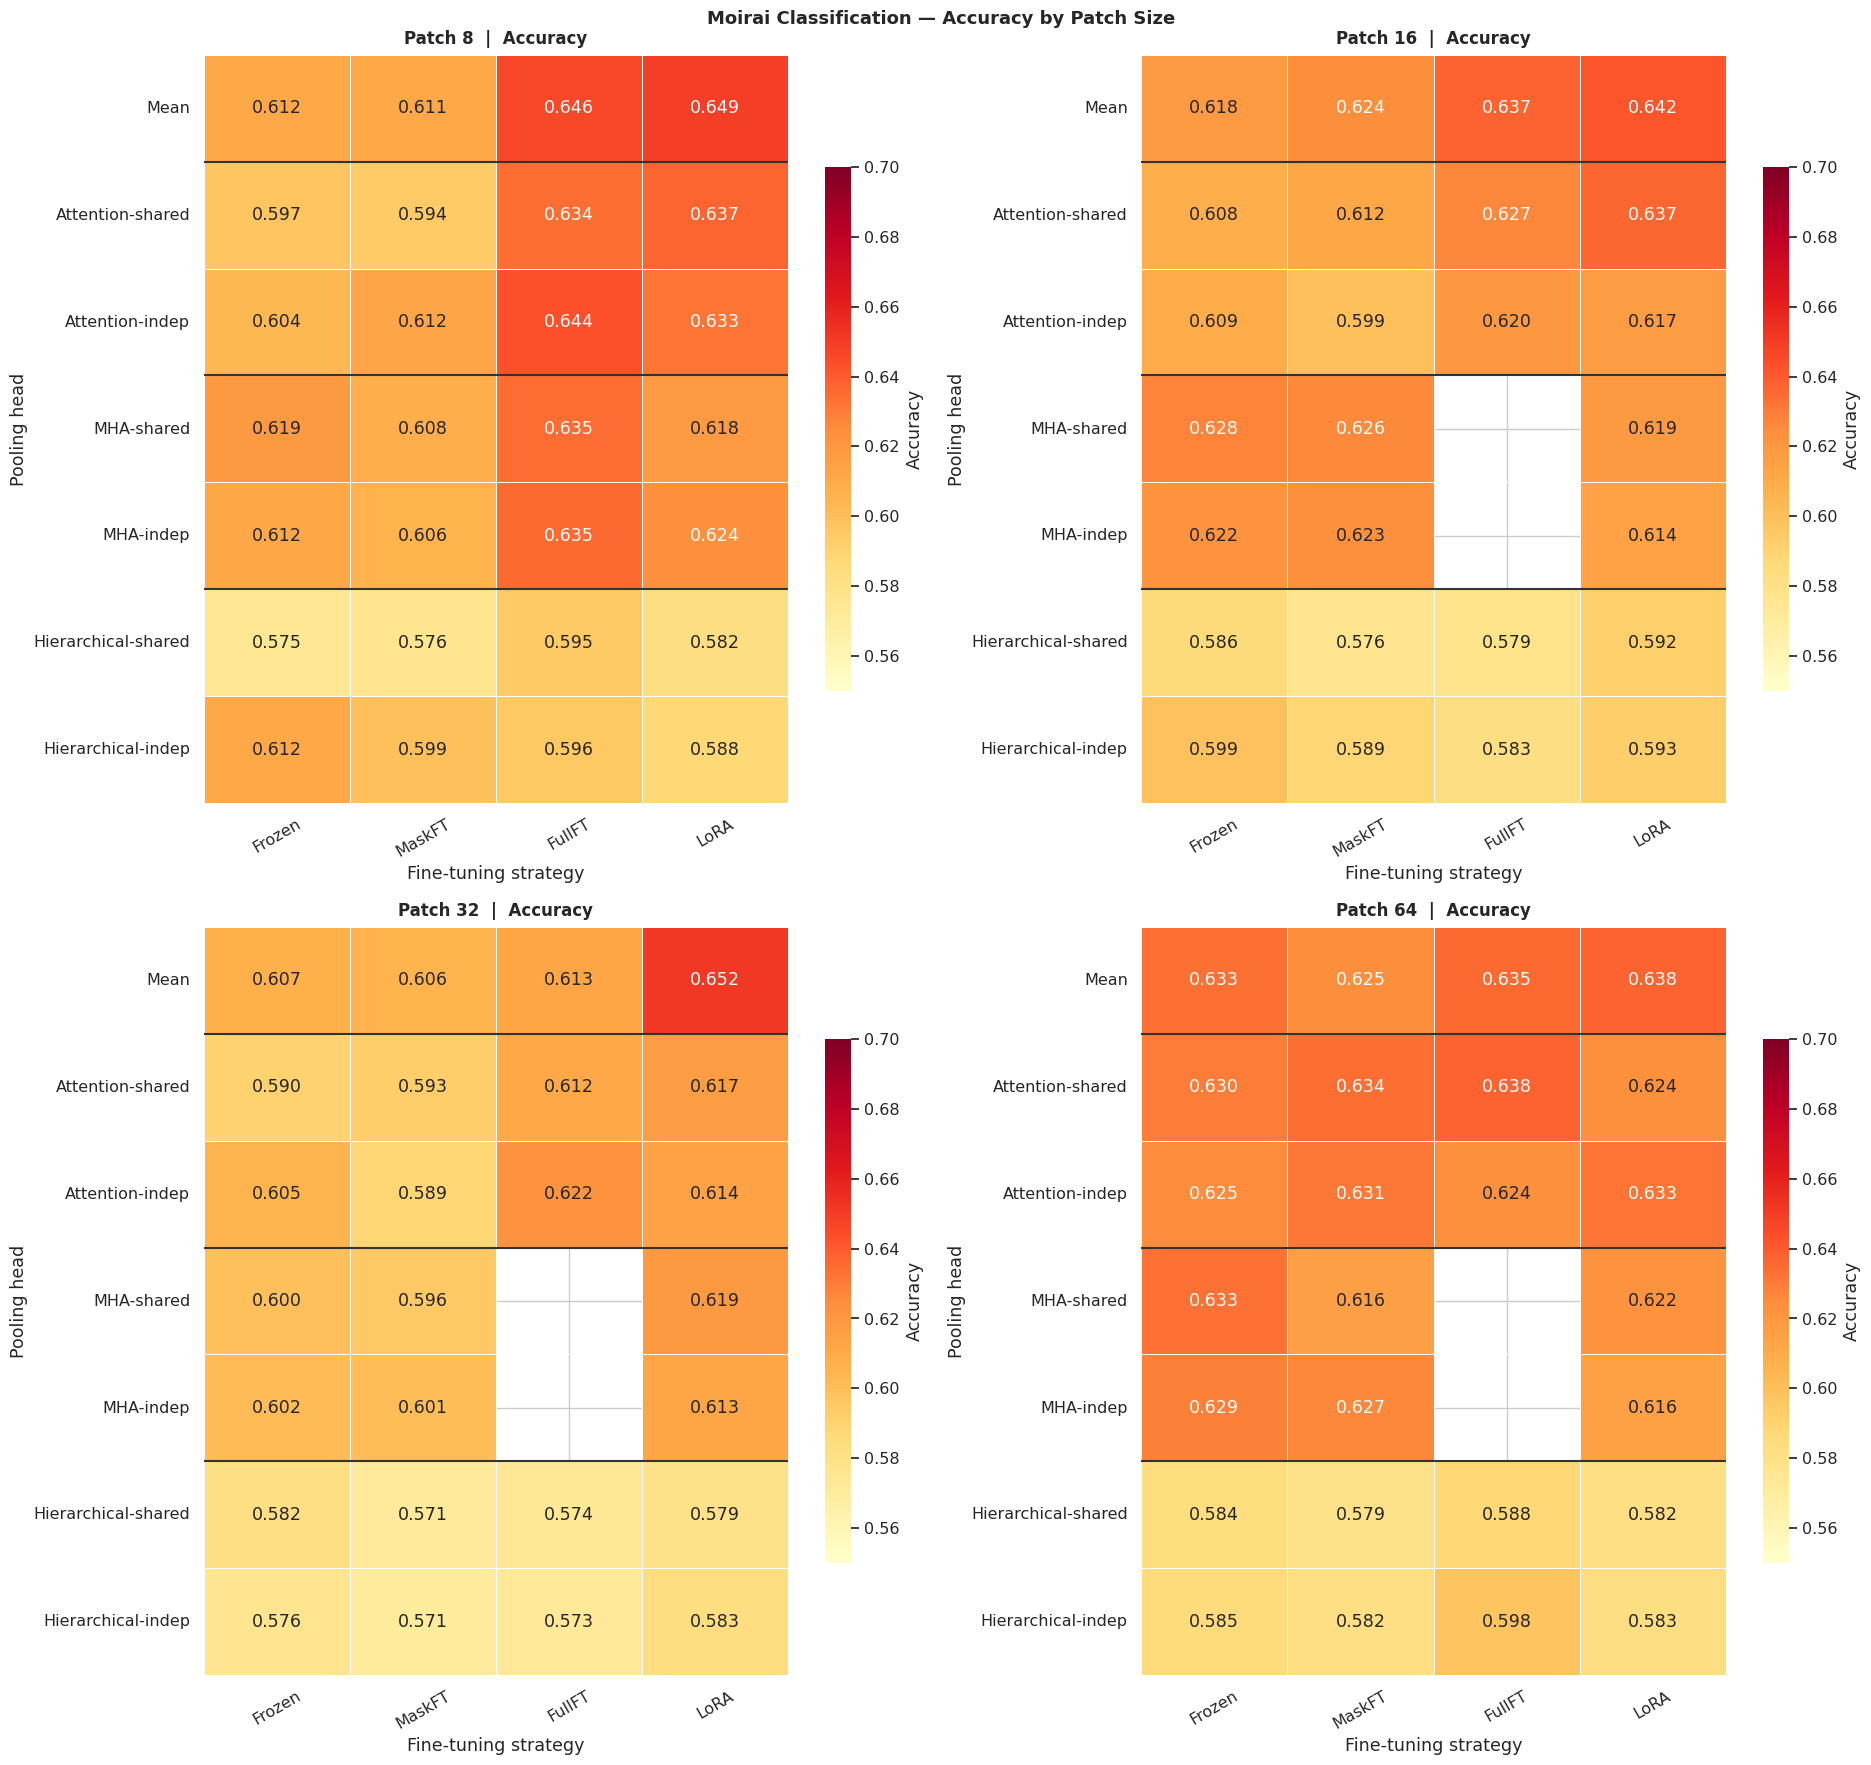

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(19, 18))

for ax, patch in zip(axes.flatten(), PATCH_SIZES):
    df_p = df_all[df_all['patch_size'] == patch].copy()
    pivot = (df_p.pivot_table(index='pooling', columns='finetuning', values='accuracy', aggfunc='first')
               .reindex(index=POOLING_ORDER, columns=FINETUNING_ORDER))
    pivot.columns = [FT_LABELS[c] for c in pivot.columns]
    draw_heatmap(ax, pivot, 'YlOrRd', 0.55, 0.70, 'Accuracy')
    ax.set_title(f'Patch {patch}  |  Accuracy', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Fine-tuning strategy')
    ax.set_ylabel('Pooling head')

plt.suptitle('Moirai Classification — Accuracy by Patch Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_csv/heatmap_all_patches.png', dpi=150, bbox_inches='tight')
plt.show()

## MHA — Number of Heads vs Fine-tuning Strategy (patch = 8)

Rows: number of attention heads (4 → 384).  
Columns: Frozen / MaskFT / FullFT / LoRA r=8 / LoRA r=64.  
LoRA results are only available for MHA-64.

In [48]:
HEADS    = [4, 8, 16, 32, 64, 128, 384]
MODES    = ['shared_context', 'independent_context']
FT_ORDER = ['Frozen', 'MaskFT', 'FullFT', 'LoRA r=8', 'LoRA r=64']

# nb02: no Model column — reconstruct index from insertion order
nb02_raw = pd.read_csv('results_csv/nb02_patch_8_metrics.csv')
nb02_raw.index = (
    ['Mean Pooling']
    + [f'Attention ({m})' for m in MODES]
    + [f'MHA-{h} ({m})' for h in HEADS for m in MODES]
    + [f'Hierarchical ({m})' for m in MODES]
)[:len(nb02_raw)]

nb03_raw = pd.read_csv('results_csv/nb03_patch_8_metrics.csv', index_col=0)
nb04_raw = pd.read_csv('results_csv/nb04_patch_8_metrics.csv', index_col=0)
nb05_raw = pd.read_csv('results_csv/nb05_patch_8_metrics.csv', index_col=0)

records = []

def collect(raw_df, ft_label):
    for h in HEADS:
        for mode in MODES:
            lbl = f'MHA-{h} ({mode})'
            if lbl in raw_df.index:
                row = raw_df.loc[lbl]
                records.append({
                    'n_heads': h, 'mode': mode, 'finetuning': ft_label,
                    'accuracy':     pd.to_numeric(row['Accuracy'],      errors='coerce'),
                    'macro_recall': pd.to_numeric(row['Macro Recall'],  errors='coerce'),
                })

def collect_lora(raw_df, rank):
    """Collect MHA results for ALL head counts with a given LoRA rank."""
    for h in HEADS:
        for mode in MODES:
            lbl = f'MHA-{h} ({mode}) LoRA r={rank}'
            if lbl in raw_df.index:
                row = raw_df.loc[lbl]
                records.append({
                    'n_heads': h, 'mode': mode, 'finetuning': f'LoRA r={rank}',
                    'accuracy':     pd.to_numeric(row['Accuracy'],      errors='coerce'),
                    'macro_recall': pd.to_numeric(row['Macro Recall'],  errors='coerce'),
                })

collect(nb02_raw, 'Frozen')
collect(nb03_raw, 'MaskFT')
collect(nb04_raw, 'FullFT')
collect_lora(nb05_raw, 8)
collect_lora(nb05_raw, 64)

df_mha = pd.DataFrame(records)
print(f'{len(df_mha)} MHA records')
display(df_mha.pivot_table(index=['mode', 'n_heads'], columns='finetuning', values='accuracy').round(4))

46 MHA records


finetuning                   Frozen  FullFT  LoRA r=64  LoRA r=8  MaskFT
mode                n_heads                                             
independent_context 4        0.6204  0.6436        NaN       NaN  0.6030
                    8        0.6135  0.6387        NaN       NaN  0.6046
                    16       0.6168  0.6395        NaN       NaN  0.6103
                    32       0.6123  0.6395        NaN       NaN  0.6062
                    64       0.6119  0.6350     0.6350    0.6241  0.6058
                    128      0.6139  0.6334        NaN       NaN  0.6075
                    384      0.6123  0.6354        NaN       NaN  0.6160
shared_context      4        0.6139  0.6476        NaN       NaN  0.6071
                    8        0.6079  0.6261        NaN       NaN  0.6026
                    16       0.6176  0.6233        NaN       NaN  0.6180
                    32       0.6115  0.6395        NaN       NaN  0.6184
                    64       0.6188  0.6346     0.6326    0.6180  0.6083
                    128      0.6192  0.6330        NaN       NaN  0.6067
                    384      0.6184  0.6310        NaN       NaN  0.6030

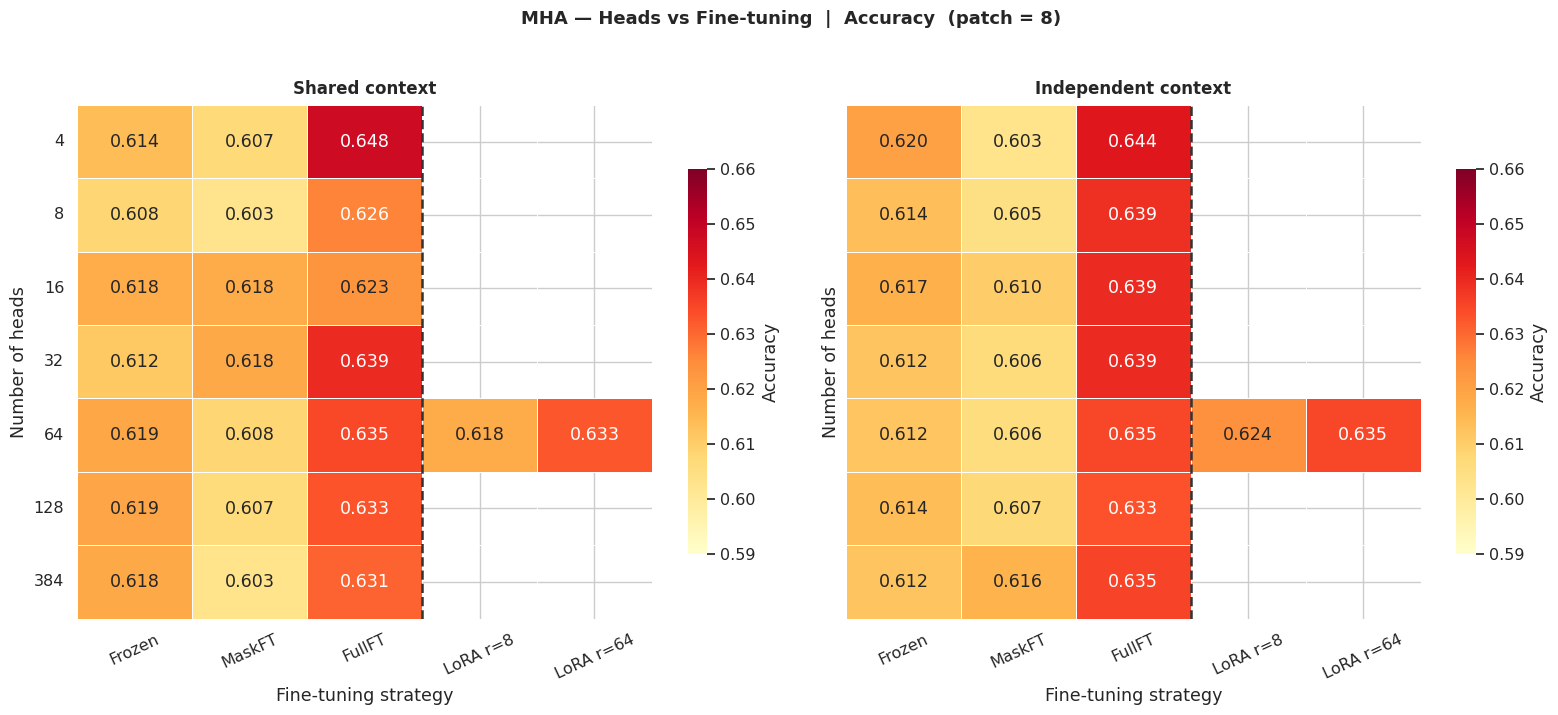

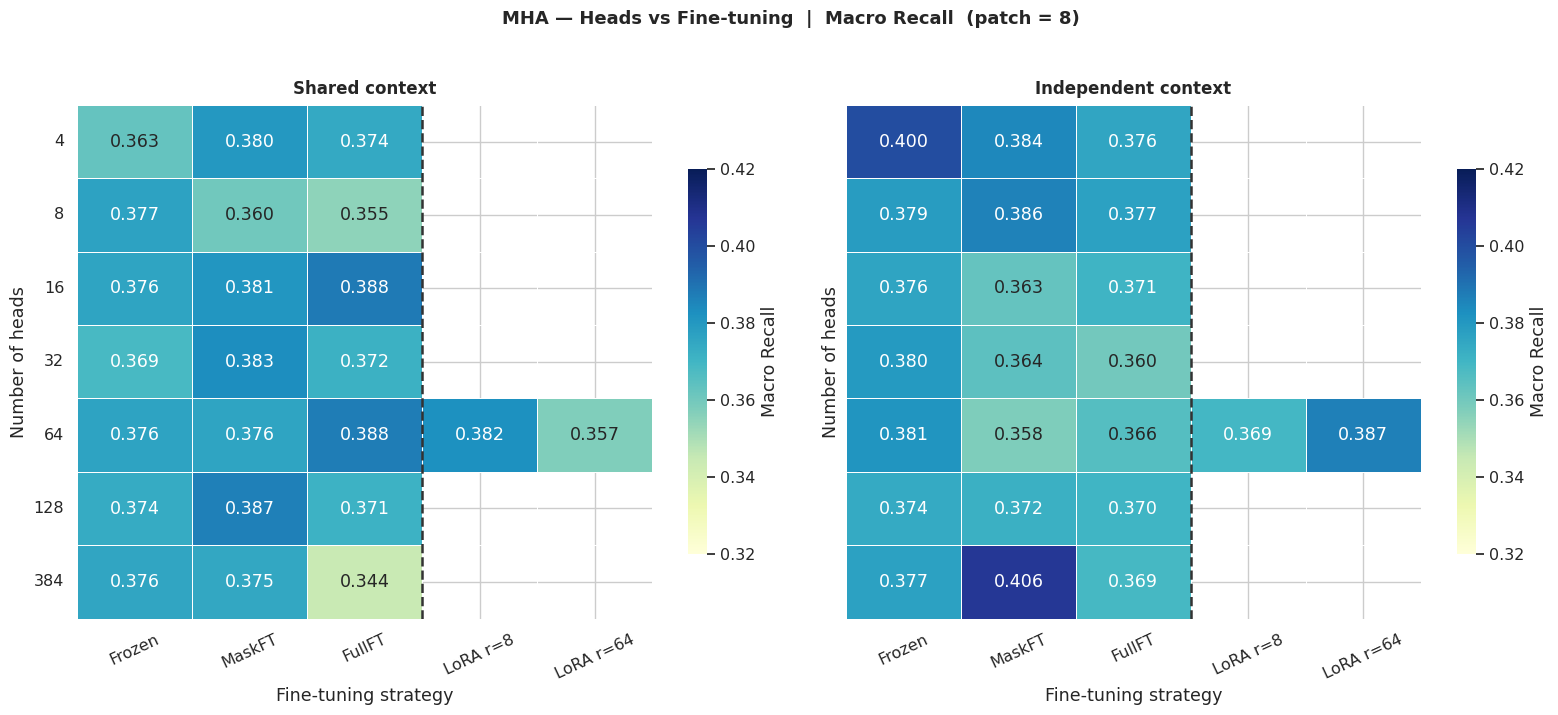

In [49]:
MODE_LABELS = {'shared_context': 'Shared context', 'independent_context': 'Independent context'}

def mha_heatmap(metric, label, vmin, vmax, cmap, path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    for ax, mode in zip(axes, MODES):
        pivot = (
            df_mha[df_mha['mode'] == mode]
            .pivot_table(index='n_heads', columns='finetuning', values=metric, aggfunc='first')
            .reindex(index=HEADS, columns=FT_ORDER)
        )
        mask  = pivot.isnull()
        annot = pivot.copy().astype(object)
        annot[mask] = ''
        sns.heatmap(pivot.astype(float), ax=ax, annot=annot, fmt='',
                    cmap=cmap, vmin=vmin, vmax=vmax,
                    linewidths=0.6, linecolor='white',
                    cbar_kws={'label': label, 'shrink': 0.75}, mask=mask)
        for t in ax.texts:
            try: t.set_text(f'{float(t.get_text()):.3f}')
            except ValueError: pass
        ax.axvline(3, color='#333333', linewidth=1.8, linestyle='--')
        ax.set_title(MODE_LABELS[mode], fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Fine-tuning strategy')
        ax.set_ylabel('Number of heads')
        ax.set_yticklabels([str(h) for h in HEADS])
        ax.tick_params(axis='x', rotation=25)
        ax.tick_params(axis='y', rotation=0)
    fig.suptitle(f'MHA — Heads vs Fine-tuning  |  {label}  (patch = 8)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

mha_heatmap('accuracy',     'Accuracy',     0.59, 0.66, 'YlOrRd', 'results_csv/heatmap_mha_heads_accuracy.png')
mha_heatmap('macro_recall', 'Macro Recall', 0.32, 0.42, 'YlGnBu', 'results_csv/heatmap_mha_heads_recall.png')

## LoRA / DoRA / AdaLoRA — Rank vs Method (patch = 8, Mean Pooling head)

/tmp/ipykernel_46717/3811763478.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: f'{x:.3f}' if pd.notna(x) else '')


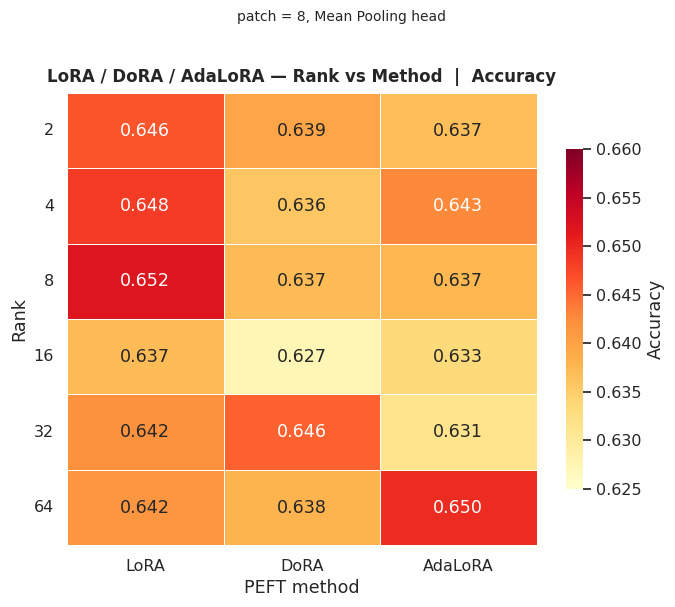

/tmp/ipykernel_46717/3811763478.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda x: f'{x:.3f}' if pd.notna(x) else '')


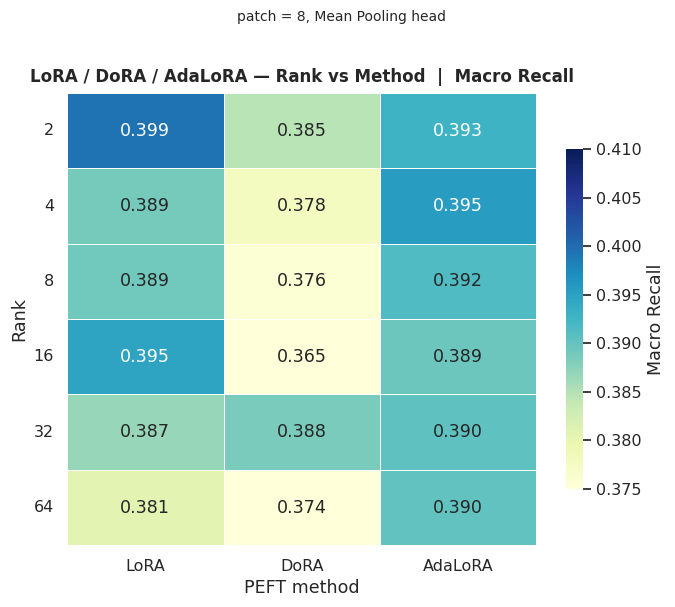

In [50]:
RANKS   = [2, 4, 8, 16, 32, 64]
METHODS = ['LoRA', 'DoRA', 'AdaLoRA']

nb05 = pd.read_csv('results_csv/nb05_patch_8_metrics.csv', index_col=0)

lora_records = []
for method in METHODS:
    for r in RANKS:
        lbl = f'{method} r={r}'
        if lbl in nb05.index:
            row = nb05.loc[lbl]
            lora_records.append({
                'method': method, 'rank': r,
                'accuracy':     pd.to_numeric(row['Accuracy'],     errors='coerce'),
                'macro_recall': pd.to_numeric(row['Macro Recall'], errors='coerce'),
            })

df_lora = pd.DataFrame(lora_records)

for metric, label, vmin, vmax, cmap, fname in [
    ('accuracy',    'Accuracy',    0.625, 0.660, 'YlOrRd', 'results_csv/heatmap_lora_rank_accuracy.png'),
    ('macro_recall','Macro Recall',0.375, 0.410, 'YlGnBu', 'results_csv/heatmap_lora_rank_recall.png'),
]:
    pivot = (
        df_lora.pivot_table(index='rank', columns='method', values=metric, aggfunc='first')
               .reindex(index=RANKS, columns=METHODS)
    )
    annot = pivot.applymap(lambda x: f'{x:.3f}' if pd.notna(x) else '')

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(pivot.astype(float), ax=ax, annot=annot, fmt='',
                cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.6, linecolor='white',
                cbar_kws={'label': label, 'shrink': 0.75})
    ax.set_title(f'LoRA / DoRA / AdaLoRA — Rank vs Method  |  {label}', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('PEFT method')
    ax.set_ylabel('Rank')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)
    plt.suptitle('patch = 8, Mean Pooling head', fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()